# Debug Q3D-MPI code

### cyl3_cylgrid

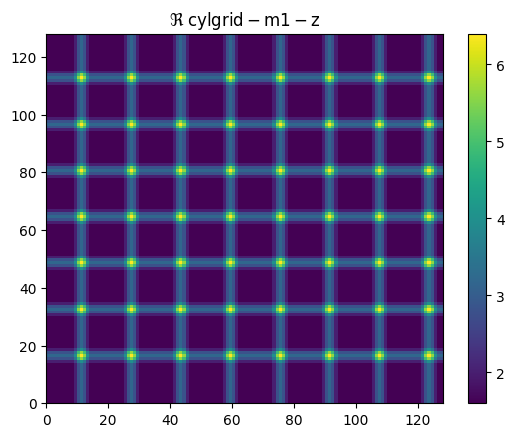

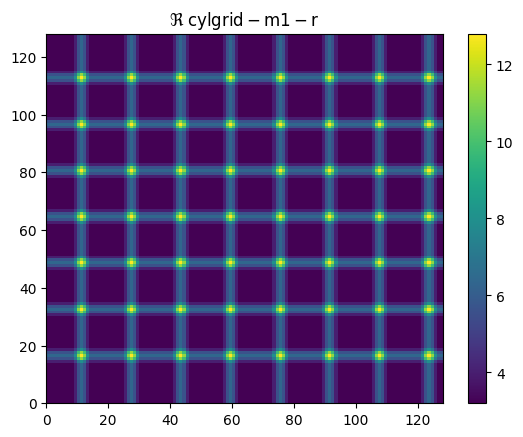

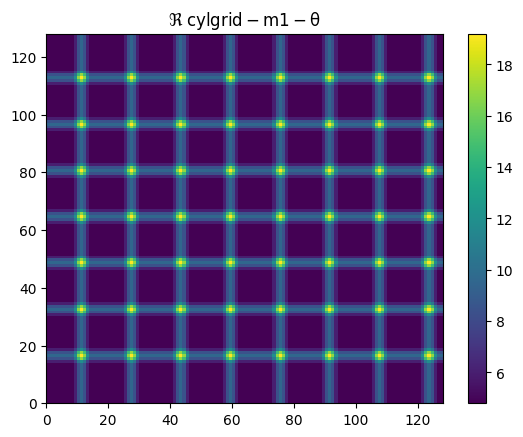

In [3]:
import visxd

# visxd.grid2d("test/cylgrid0_z.zdf" )
# visxd.grid2d("test/cylgrid0_r.zdf" )
# visxd.grid2d("test/cylgrid0_th.zdf" )

visxd.complex_grid2d("test/cylgrid1_z.zdf", part = 'real' )
visxd.complex_grid2d("test/cylgrid1_r.zdf", part = 'real' )
visxd.complex_grid2d("test/cylgrid1_th.zdf", part = 'real' )

### Laser test

`test_laser()`


In [10]:
! make -j 12 && mpirun -np 4 ./zpic

[c++]  laser.cpp
[link]  zpic
Environment
MPI running on 4 processes
GPU devices on rank 0 (GPUA100):
Device Number           : 0 (of 1)
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 
Running test_laser()...
Using dt = 0.0175145
(*info*) Created (2, 2) Partition object
Completed test_laser()



#### Electric field

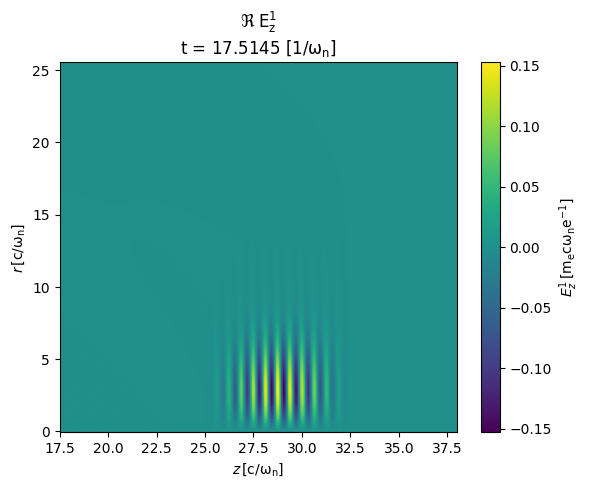

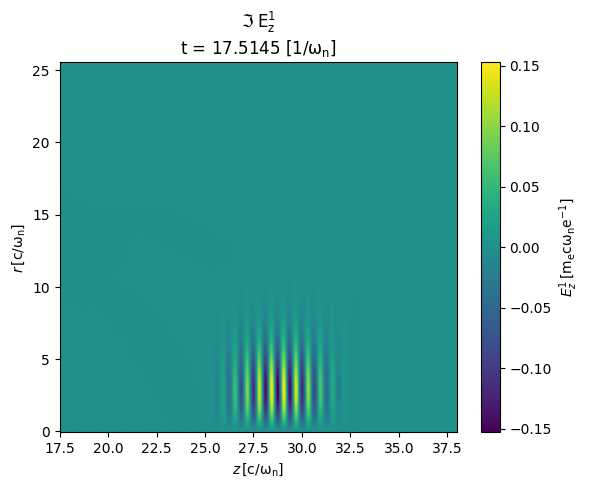

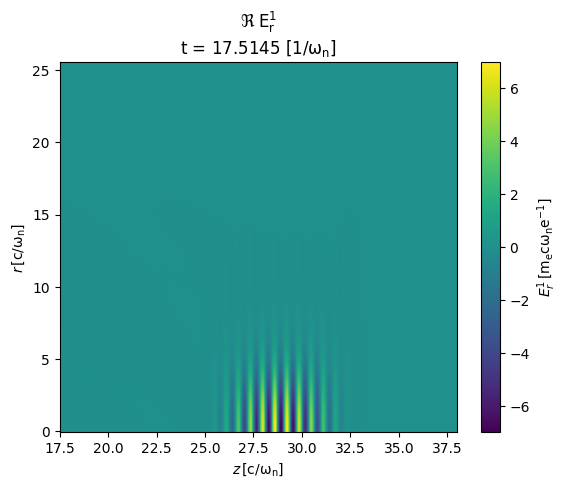

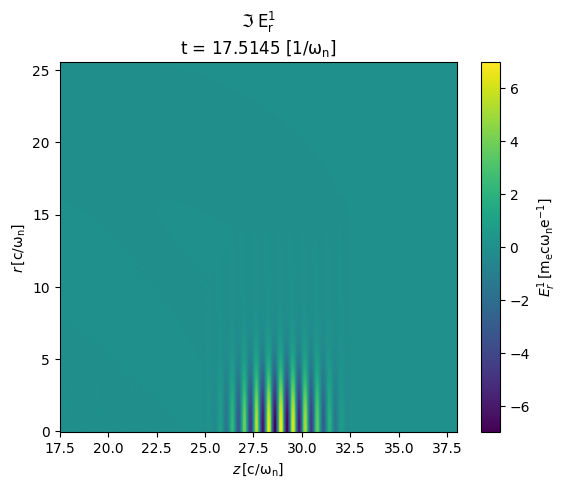

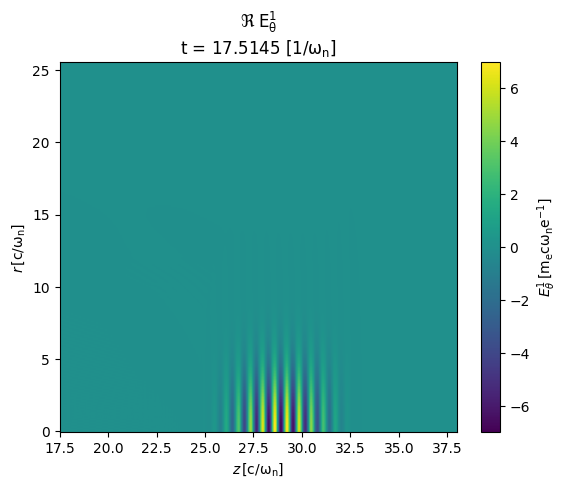

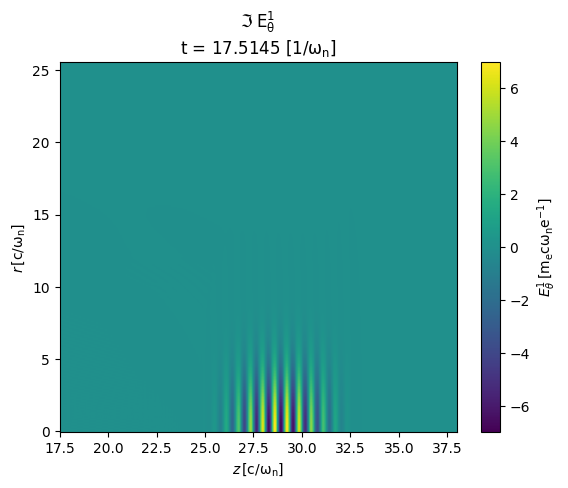

In [6]:
import visxd
import matplotlib.colors as colors

import importlib
importlib.reload( visxd )

def fname( comp, iter ):
    return "EMF/{:s}-{:06d}.zdf".format( comp, iter )

# ! ls EMF/*.zdf

# iter = 0
iter = 1000

visxd.complex_grid2d(fname("E1z", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("E1z", iter), part = 'imag', vsim = True )
visxd.complex_grid2d(fname("E1r", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("E1r", iter), part = 'imag', vsim = True )
visxd.complex_grid2d(fname("E1θ", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("E1θ", iter), part = 'imag', vsim = True )




#### Magnetic field

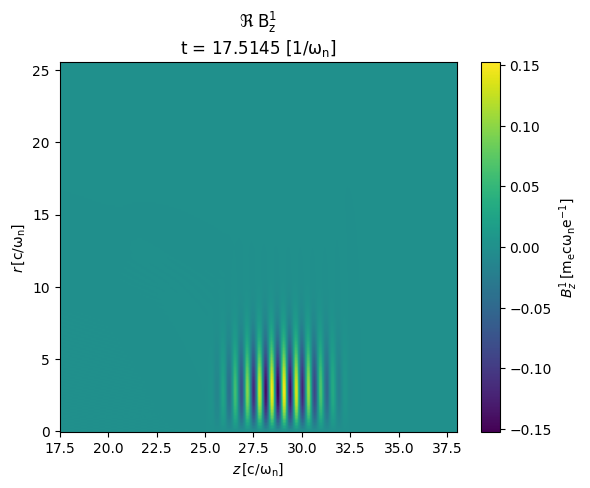

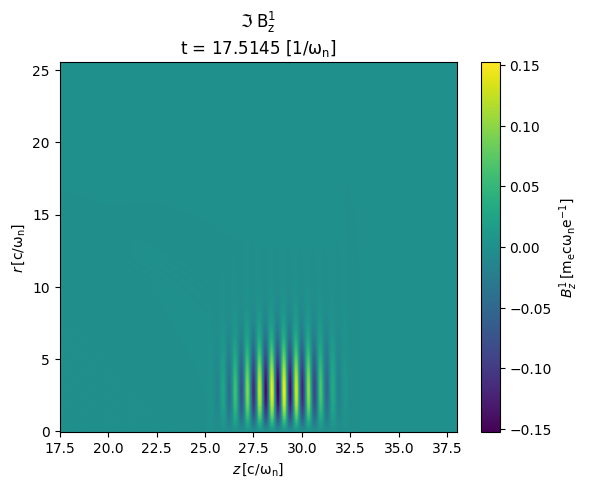

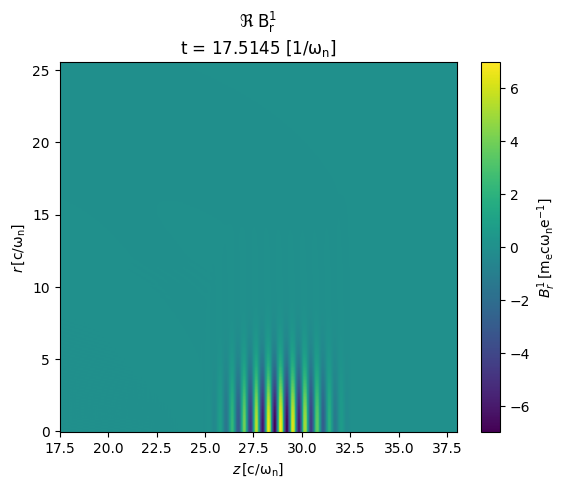

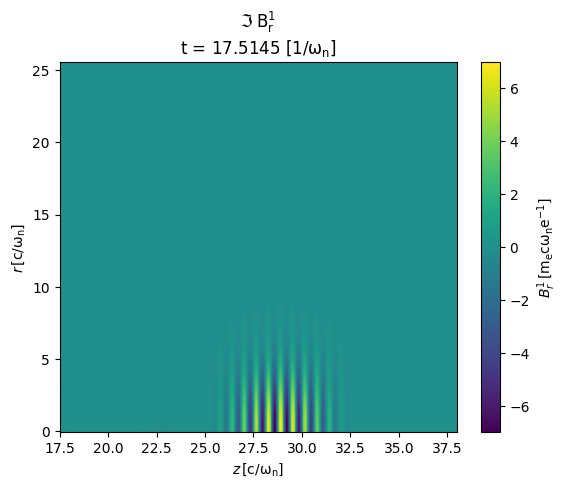

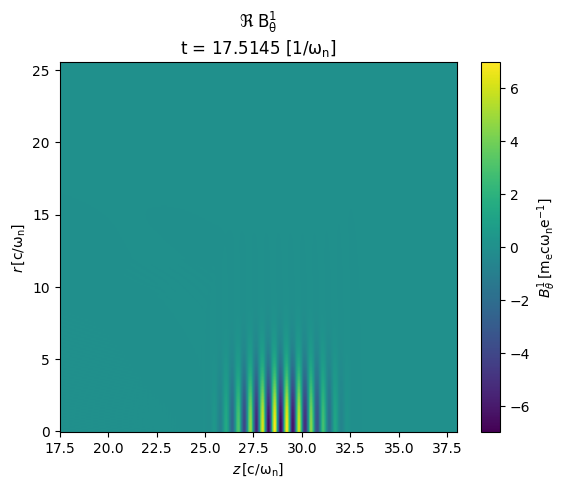

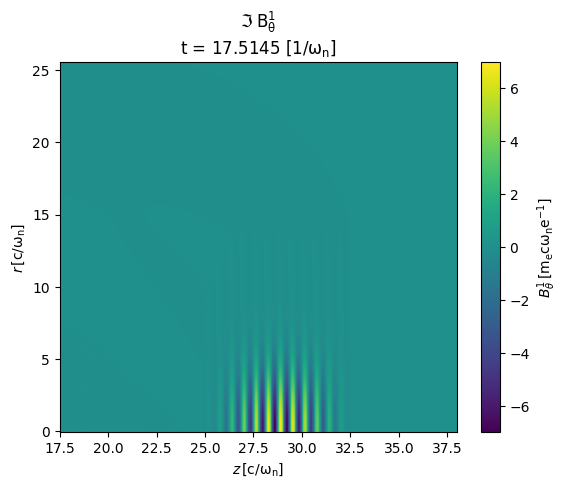

In [7]:
import visxd
import matplotlib.colors as colors

import importlib
importlib.reload( visxd )

def fname( comp, iter ):
    return "EMF/{:s}-{:06d}.zdf".format( comp, iter )

# ! ls EMF/*.zdf

# iter = 0
iter = 1000

visxd.complex_grid2d(fname("B1z", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("B1z", iter), part = 'imag', vsim = True )
visxd.complex_grid2d(fname("B1r", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("B1r", iter), part = 'imag', vsim = True )
visxd.complex_grid2d(fname("B1θ", iter), part = 'real', vsim = True )
visxd.complex_grid2d(fname("B1θ", iter), part = 'imag', vsim = True )

### Particle Injection test


In [8]:
! make -j 12 && mpirun -np 4 ./zpic

make: Nothing to be done for 'all'.
Environment
MPI running on 4 processes
GPU devices on rank 0 (GPUA100):
Device Number           : 0 (of 1)
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 
Running test_inj()...
Completed test_inj()


Plotting PARTICLES/electrons/particles-electrons-000000.zdf


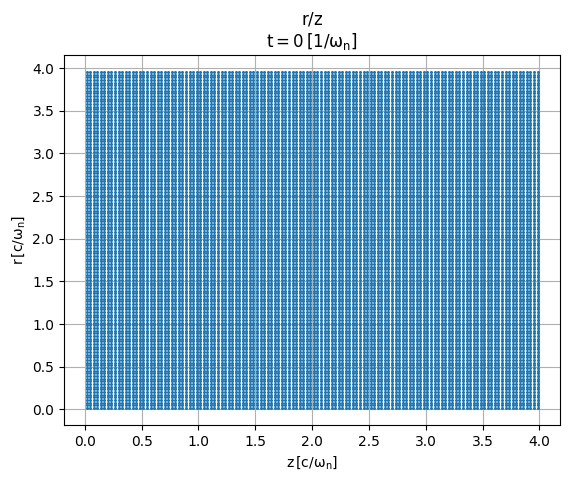

Plotting PARTICLES/electrons/particles-electrons-000000.zdf


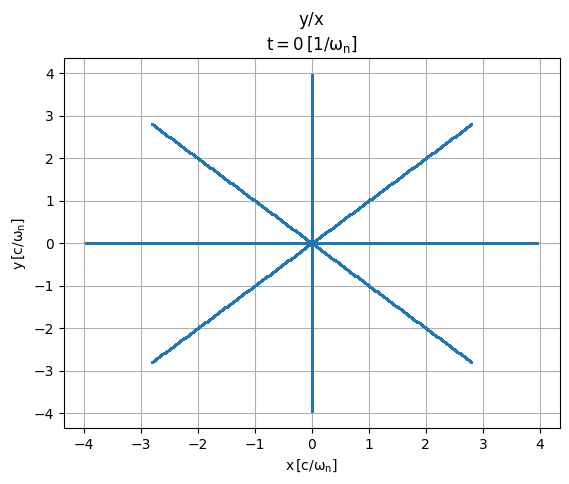

Plotting PARTICLES/electrons/particles-electrons-000000.zdf


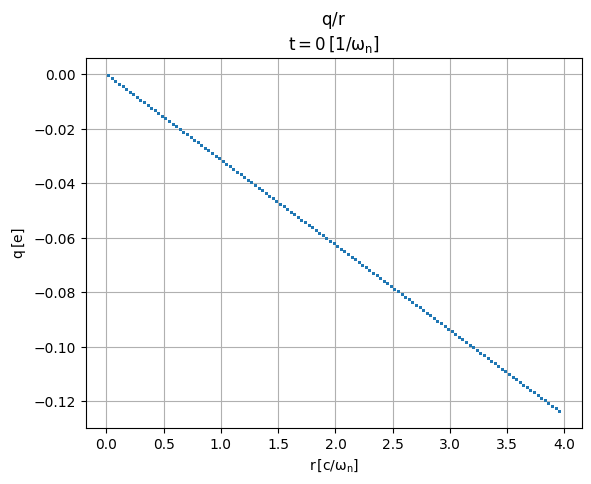

Plotting CHARGE/electrons/electrons-ρ0-000000.zdf


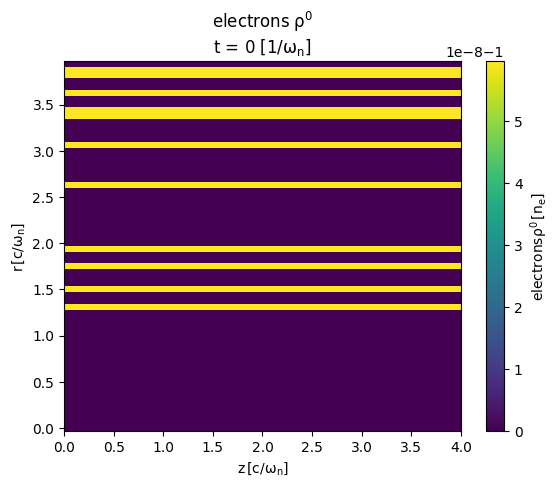

In [20]:
import visxd

visxd.plot_part("PARTICLES/electrons/particles-electrons", 0 )
visxd.plot_part("PARTICLES/electrons/particles-electrons", 0, qx = 'x', qy = 'y' )
visxd.plot_part("PARTICLES/electrons/particles-electrons", 0, qx = 'r', qy = 'q' )

visxd.plot_data("CHARGE/electrons/electrons-ρ0", 0)



### Particle motion test

In [23]:
! make -j 12 && mpirun -np 4 ./zpic

make: Nothing to be done for 'all'.
Environment
MPI running on 4 processes
GPU devices on rank 0 (GPUA100):
Device Number           : 0 (of 1)
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 
Running test_mov()...
Completed test_mov()


Plotting CHARGE/electrons/electrons-ρ0-000000.zdf


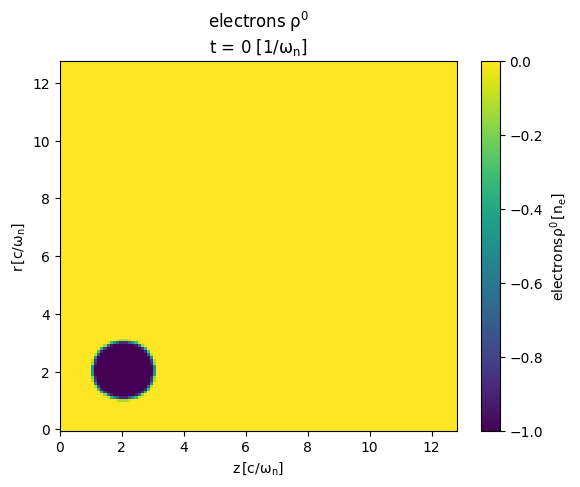

Plotting CHARGE/electrons/electrons-ρ0-000100.zdf


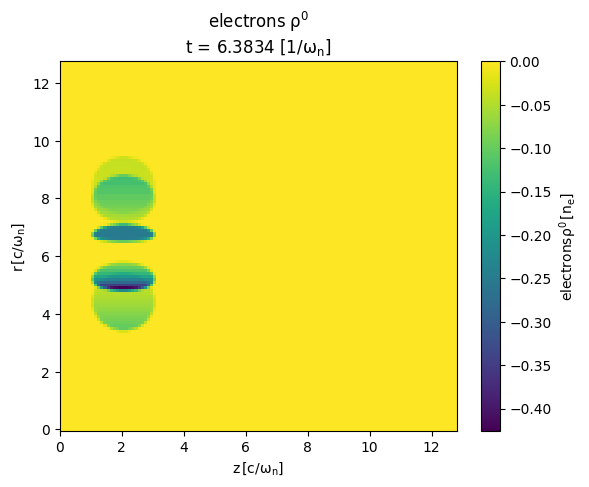

Plotting PARTICLES/electrons/particles-electrons-000100.zdf


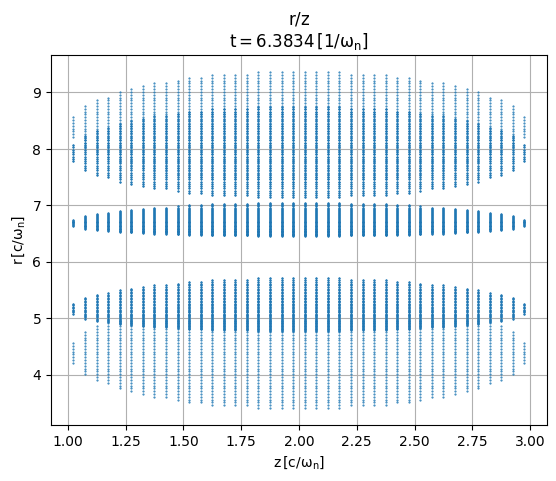

In [44]:
import visxd

visxd.plot_data("CHARGE/electrons/electrons-ρ0", 0)
visxd.plot_data("CHARGE/electrons/electrons-ρ0", 100)
visxd.plot_part("PARTICLES/electrons/particles-electrons", 100 )

### Current deposit test

**Note**: The imaginary part of current and fields (for any m > 0) will have the opposite sign from the OSIRIS implementation.

In [70]:
! make -j 12 && mpirun -np 4 ./zpic

[c++]  current.cpp
[link] zpic
quasi-3D tests
SIMD support not enabled
OpenMP enabled
  # procs           : 14
  max_threads       : 14
  default # threads : 14
Running test_current()...
Completed test_current()


#### Current and charge, m = 0

Plotting CHARGE/electrons/electrons-ρ0-000001.zdf


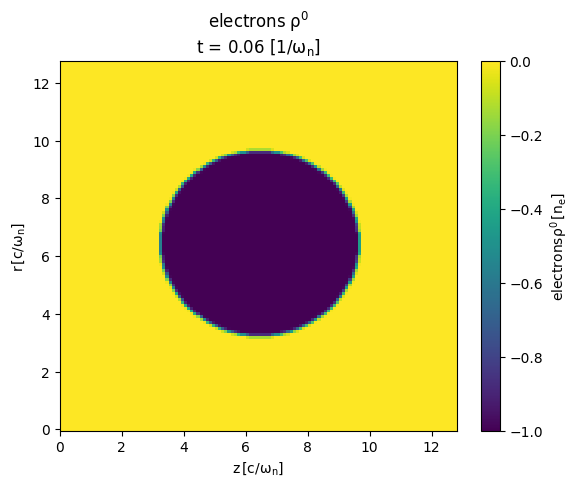

Plotting CURRENT/J0z-000001.zdf


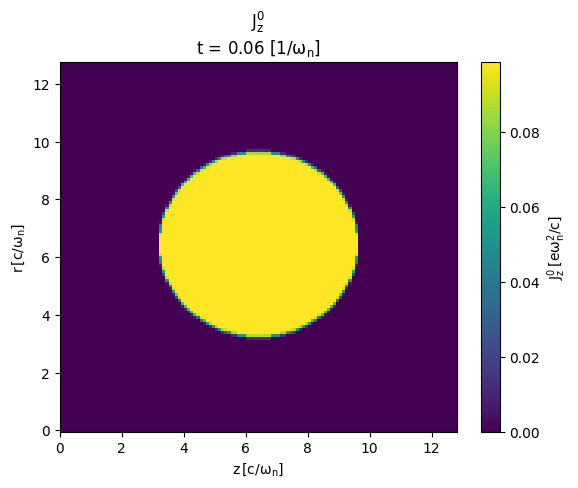

Plotting CURRENT/J0r-000001.zdf


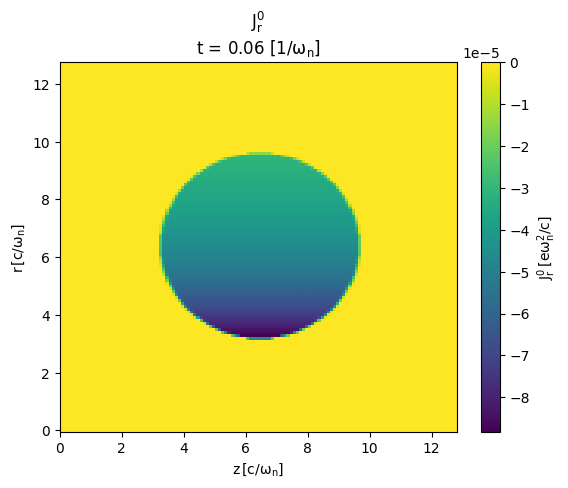

Plotting CURRENT/J0θ-000001.zdf


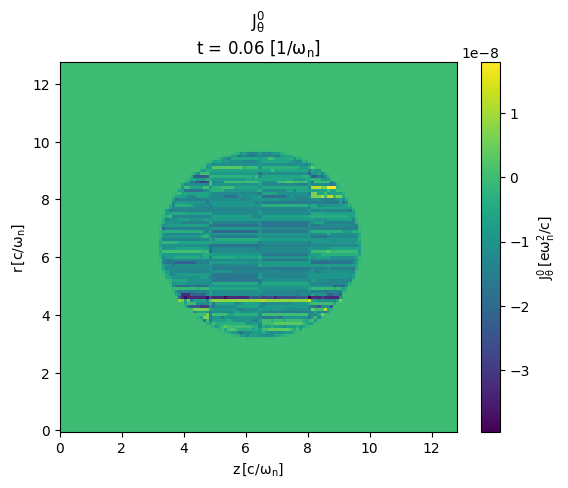

In [45]:
import visxd

iter = 1

visxd.plot_data("CHARGE/electrons/electrons-ρ0", iter)

visxd.plot_data("CURRENT/J0z", iter)
visxd.plot_data("CURRENT/J0r", iter)
visxd.plot_data("CURRENT/J0θ", iter)

#### Current m = 1

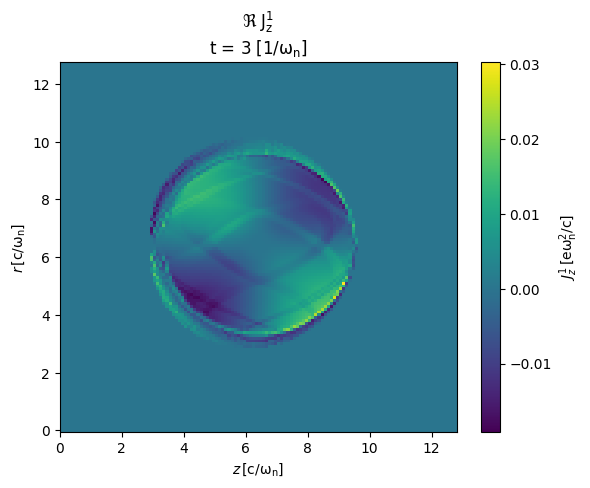

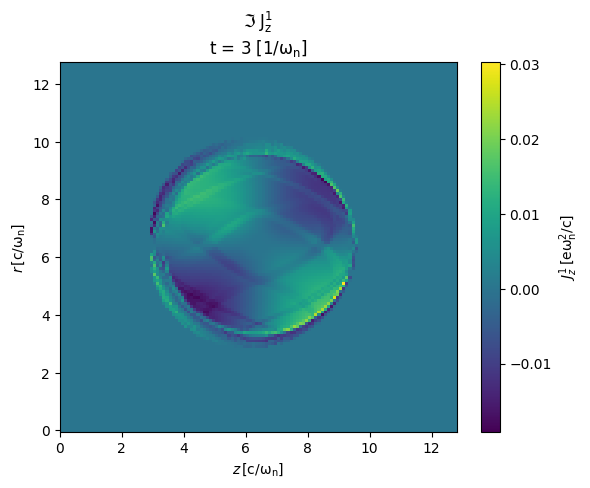

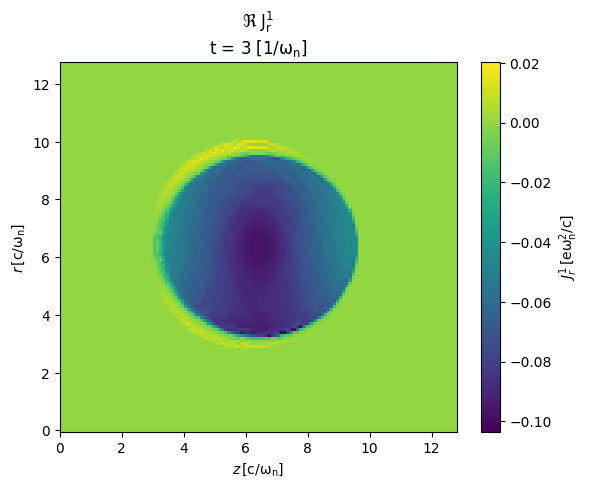

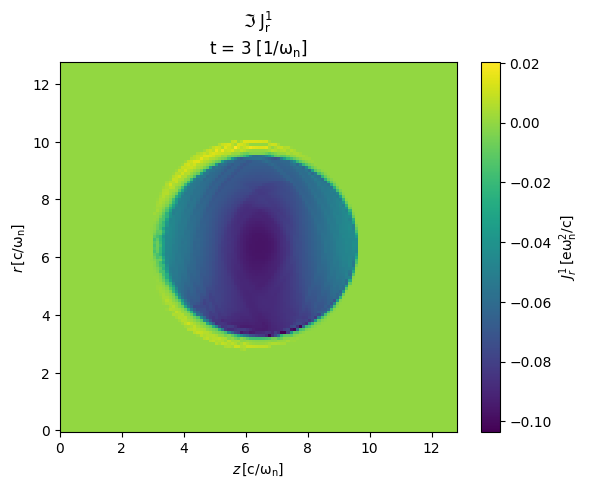

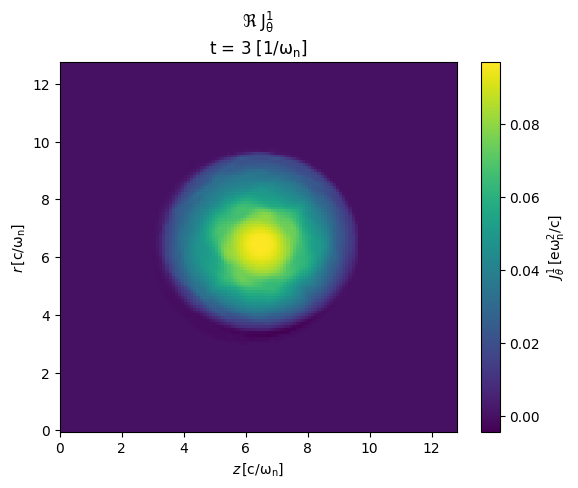

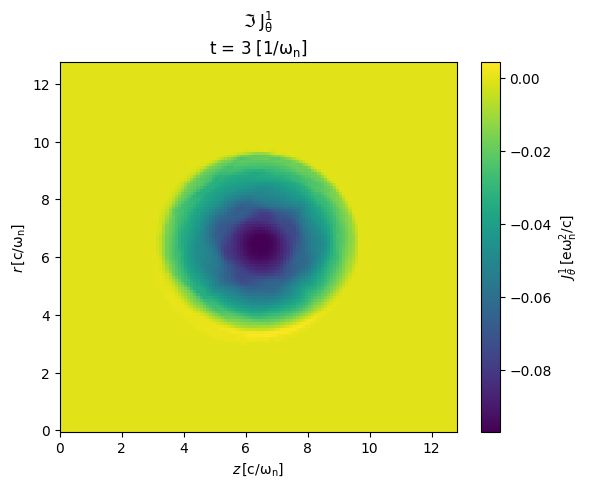

In [46]:
import visxd

def fname( comp, iter ):
    return "CURRENT/{:s}-{:06d}.zdf".format( comp, iter )

iter = 50

# visxd.plot_data("CHARGE/electrons/electrons-ρ1", iter)

visxd.complex_grid2d(fname("J1z", iter), part = 'real' )
visxd.complex_grid2d(fname("J1z", iter), part = 'imag' )
visxd.complex_grid2d(fname("J1r", iter), part = 'real' )
visxd.complex_grid2d(fname("J1r", iter), part = 'imag' )
visxd.complex_grid2d(fname("J1θ", iter), part = 'real' )
visxd.complex_grid2d(fname("J1θ", iter), part = 'imag' )

#### Electric field

Mode m = 1

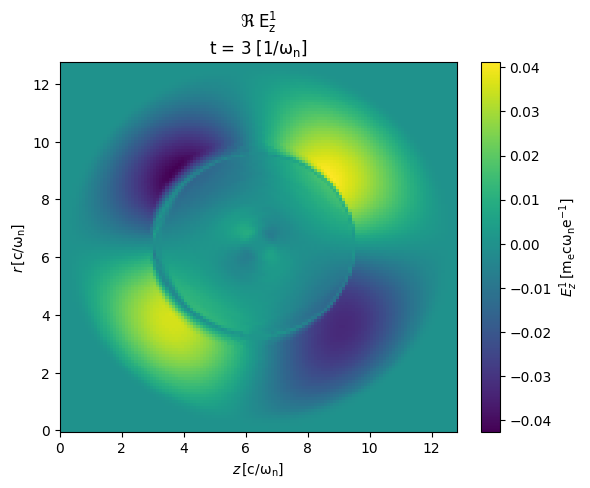

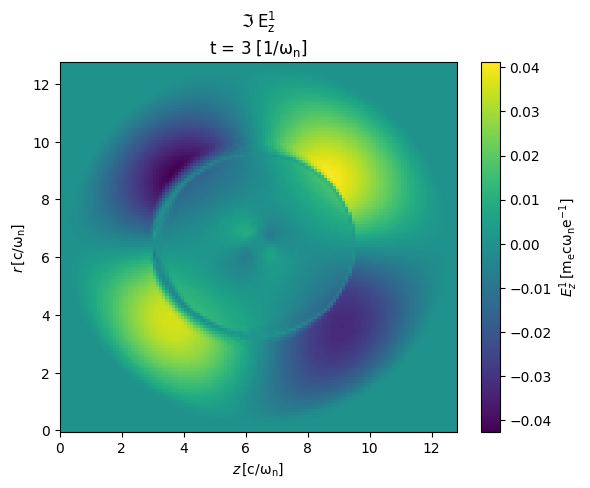

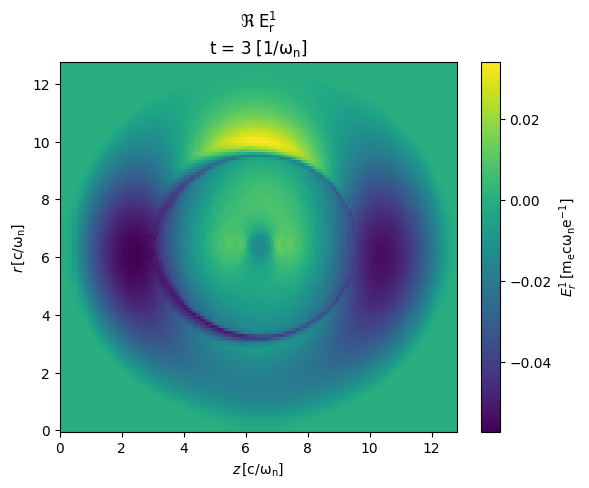

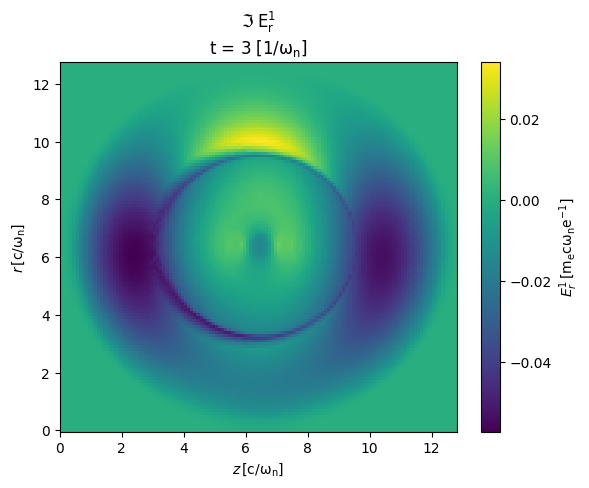

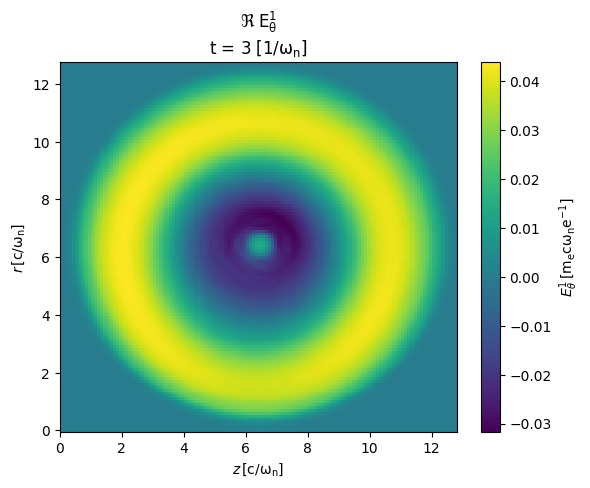

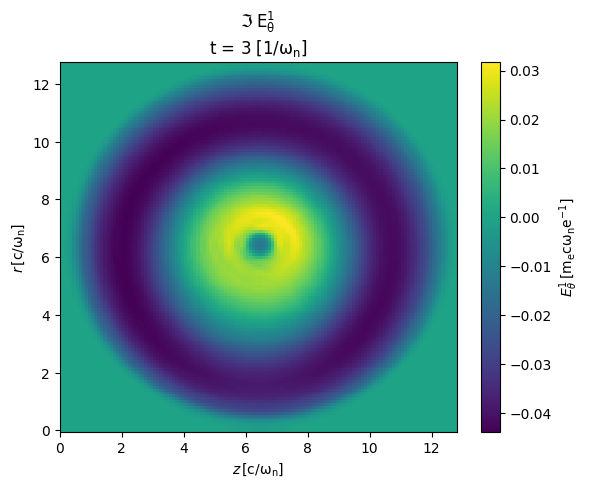

In [47]:
def fname( comp, iter ):
    return "EMF/{:s}-{:06d}.zdf".format( comp, iter )

iter = 50

visxd.complex_grid2d(fname("E1z", iter), part = 'real' )
visxd.complex_grid2d(fname("E1z", iter), part = 'imag' )

visxd.complex_grid2d(fname("E1r", iter), part = 'real' )
visxd.complex_grid2d(fname("E1r", iter), part = 'imag' )

visxd.complex_grid2d(fname("E1θ", iter), part = 'real' )
visxd.complex_grid2d(fname("E1θ", iter), part = 'imag' )

### Beam test

In [75]:
! make -j 12 && mpirun -np 4 ./zpic

[c++]  main.cpp
[link] zpic
dt     = 0.0322394
ntiles = (8, 8)
quasi-3D tests
SIMD support not enabled
OpenMP enabled
dt     = 0.0322394
ntiles = (8, 8)
dt     = 0.0322394
ntiles = (8, 8)
  # procs           : 14
  max_threads       : 14
  default # threads : 14
Running test_beam()...
dt     = 0.0322394
ntiles = (8, 8)
Completed test_beam()


Plotting CHARGE/electrons/electrons-ρ0-001000.zdf


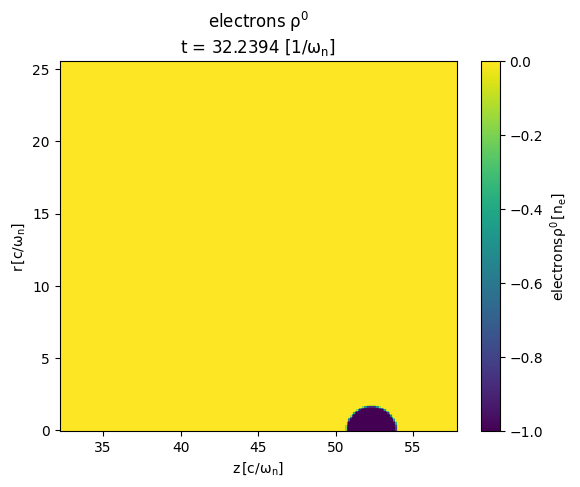

Plotting EMF/E0z-001000.zdf


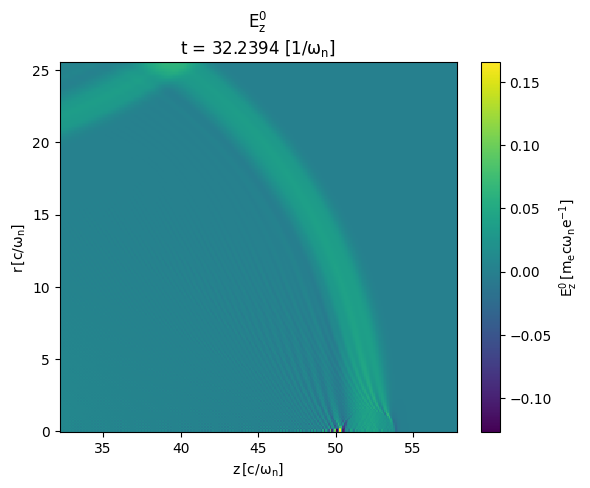

Plotting EMF/E0r-001000.zdf


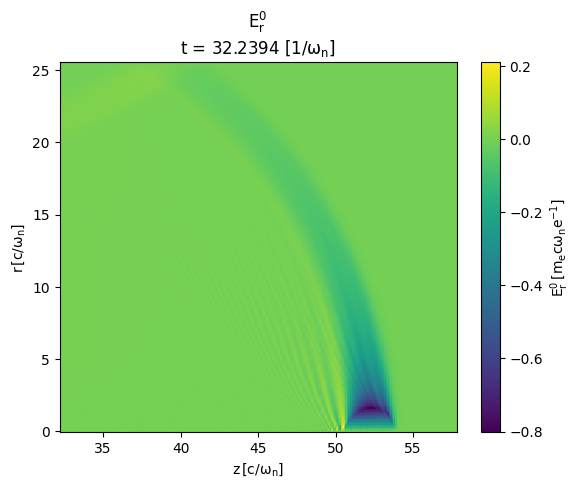

Plotting EMF/E0θ-001000.zdf


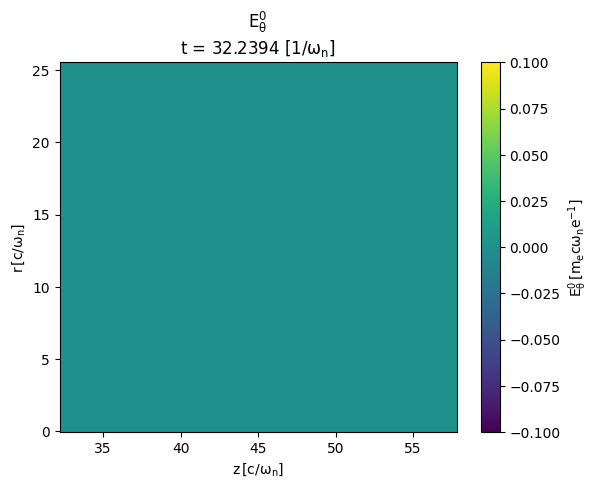

Plotting EMF/B0z-001000.zdf


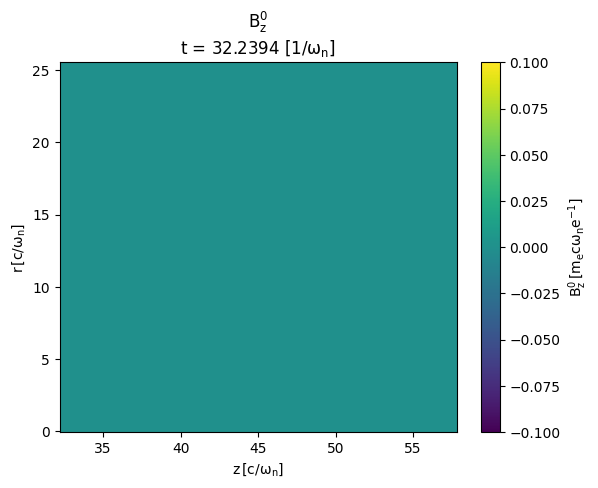

Plotting EMF/B0r-001000.zdf


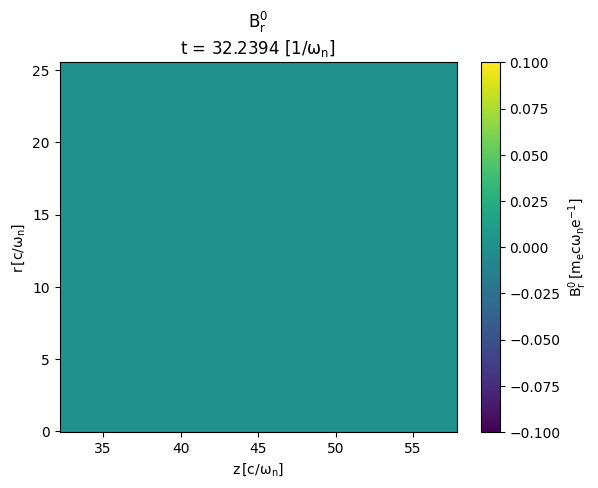

Plotting EMF/B0θ-001000.zdf


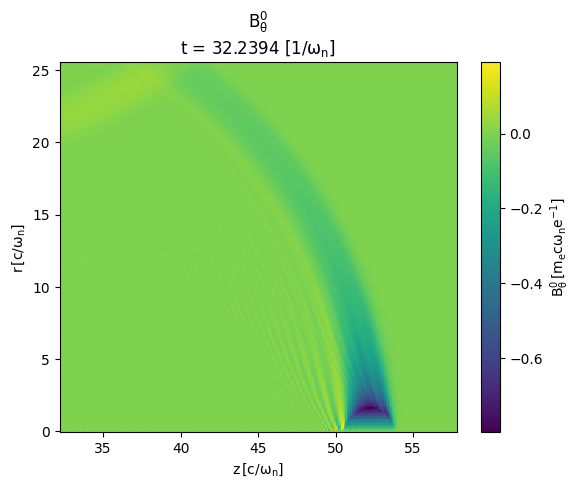

In [48]:
import visxd

iter = 1000

visxd.plot_data("CHARGE/electrons/electrons-ρ0", iter )

visxd.plot_data("EMF/E0z", iter )
visxd.plot_data("EMF/E0r", iter )
visxd.plot_data("EMF/E0θ", iter )

visxd.plot_data("EMF/B0z", iter )
visxd.plot_data("EMF/B0r", iter )
visxd.plot_data("EMF/B0θ", iter )

### PWFA test

In [49]:
! make -j 12 && mpirun -np 4 ./zpic

[c++]  main.cpp
[link]  zpic
Environment
MPI running on 4 processes
GPU devices on rank 0 (GPUA100):
Device Number           : 0 (of 1)
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 
Running test_pwfa()...
dt     = 0.0344924
ntiles = (8, 8)
dt     = 0.0344924
ntiles = (8, 8)
dt     = 0.0344924
ntiles = (8, 8)
dt     = 0.0344924
ntiles = (8, 8)
Completed test_pwfa()


Plotting CHARGE/beam/beam-ρ0-001780.zdf


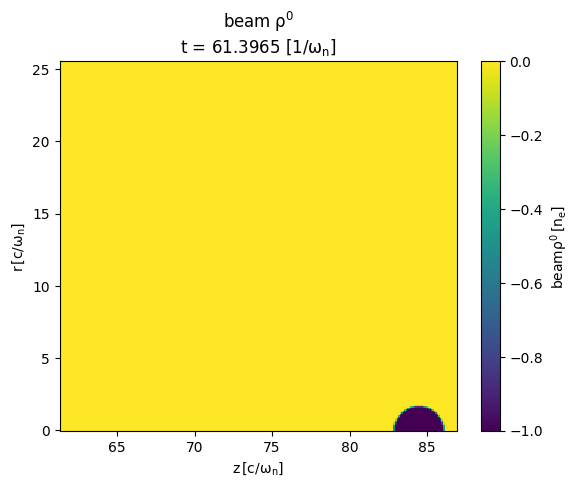

Plotting CHARGE/plasma/plasma-ρ0-001780.zdf


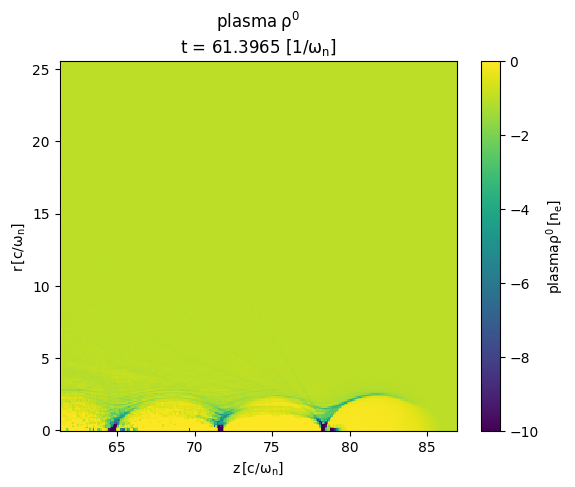

Plotting PARTICLES/plasma/particles-plasma-001780.zdf


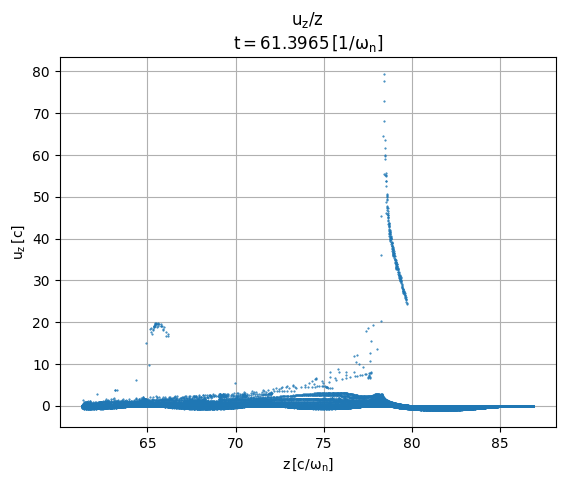

In [50]:
import visxd

iter = 1780

visxd.plot_data("CHARGE/beam/beam-ρ0", iter )
visxd.plot_data("CHARGE/plasma/plasma-ρ0", iter, vmin = -10 )

visxd.plot_part("PARTICLES/plasma/particles-plasma", iter, qy = 'uz' )

# visxd.plot_data("CURRENT/J0z", iter )


# visxd.plot_data("EMF/E0z", iter )
# visxd.plot_data("EMF/E0r", iter )
# visxd.plot_data("EMF/E0θ", iter )


# visxd.plot_data("EMF/B0z", iter )
# visxd.plot_data("EMF/B0r", iter )
# visxd.plot_data("EMF/B0θ", iter )


#visxd.plot_data("CURRENT/J0r", iter )
#visxd.plot_data("CURRENT/J0θ", iter )

### LWFA test

In [30]:
! make -j 12 && mpirun -np 4 ./zpic

make: Nothing to be done for 'all'.
Environment
MPI running on 4 processes
GPU devices on rank 0 (GPUA100):
Device Number           : 0 (of 1)
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 
Running test_lwfa()...
Starting simulation, dt = 0.0175145
i = 0
i = 100
i = 200
i = 300
i = 400
i = 500
i = 600
i = 700
i = 800
i = 900
i = 1000
i = 1100
i = 1200
Simulation run up to t = 21.5078 in 74.6124 s
Done!


Plotting EMF/E0z-000500.zdf


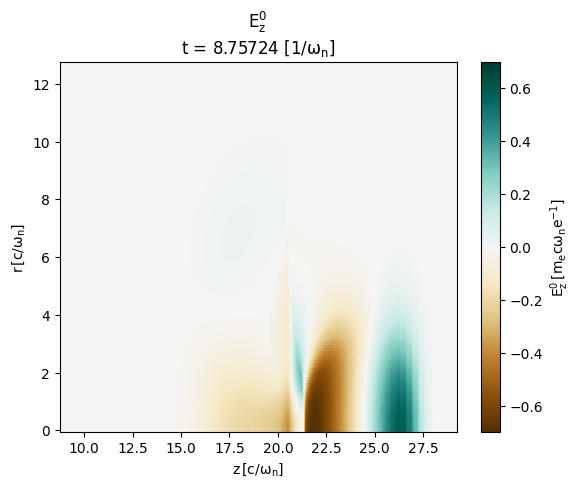

In [ ]:
import visxd

# iter = 500
iter = 1200

visxd.plot_data("EMF/E0z", iter, vsim = True, cmap = "BrBG" )
#visxd.plot_data("EMF/E0r", iter, vsim = True, cmap = "BrBG" )
#visxd.plot_data("EMF/E0θ", iter )

# visxd.plot_data("CHARGE/electrons/electrons-ρ0", iter )

#visxd.plot_data("CURRENT/J0z", iter , vsim = True, cmap = "BrBG" )
#visxd.plot_data("CURRENT/J0r", iter , vsim = True, cmap = "BrBG" )
#visxd.plot_data("CURRENT/J0θ", iter , vsim = True, cmap = "BrBG" )

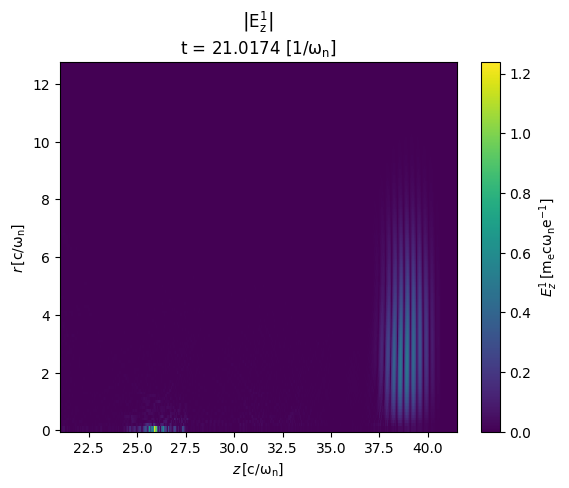

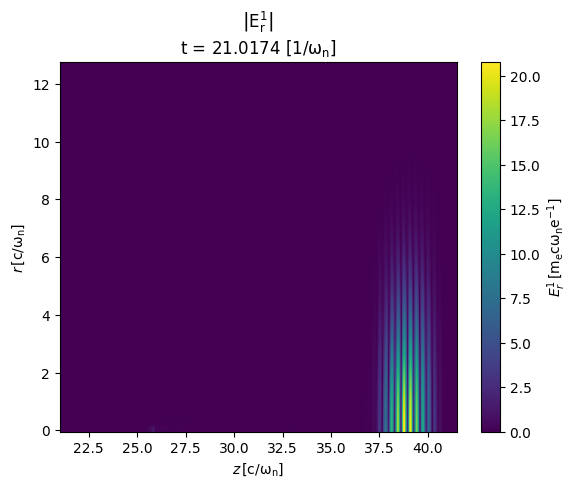

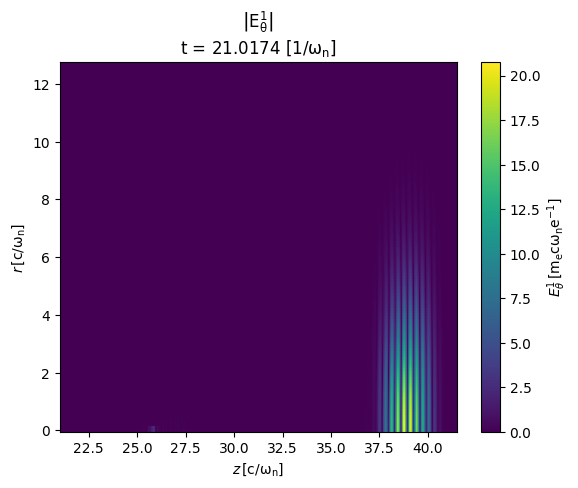

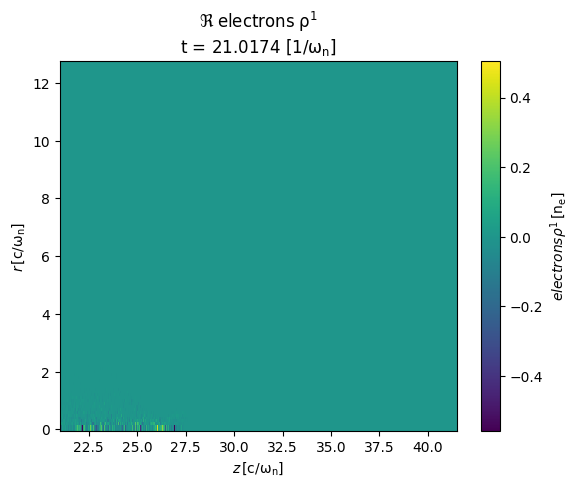

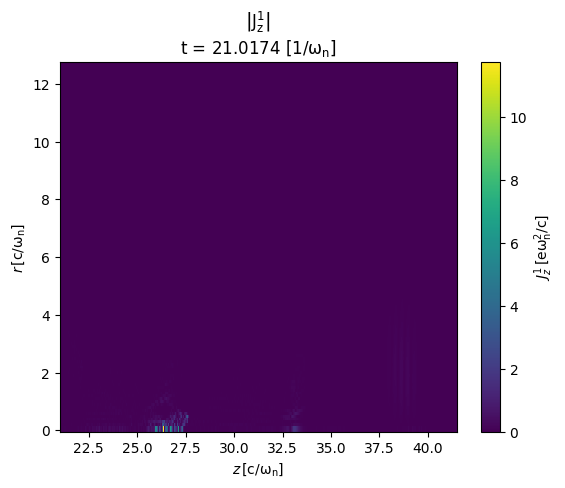

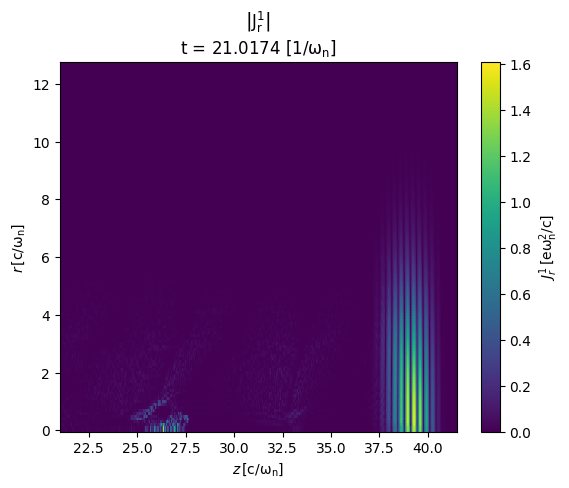

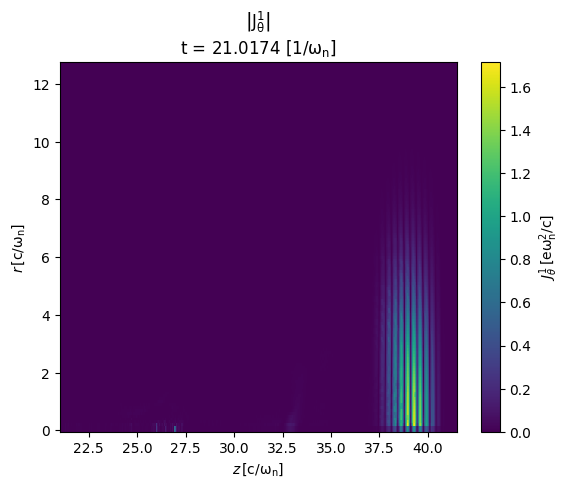

In [2]:
import visxd

def fname( folder, comp, iter ):
    return "{:s}/{:s}-{:06d}.zdf".format( folder, comp, iter )


# ! ls EMF

iter = 1200

visxd.complex_grid2d(fname("EMF", "E1z", iter), part = 'abs' )
visxd.complex_grid2d(fname("EMF", "E1r", iter), part = 'abs' )
visxd.complex_grid2d(fname("EMF", "E1θ", iter), part = 'abs' )

visxd.complex_grid2d(fname("CHARGE/electrons", "electrons-ρ1", iter), part = 'real' )

visxd.complex_grid2d(fname("CURRENT", "J1z", iter), part = 'abs' )
visxd.complex_grid2d(fname("CURRENT", "J1r", iter), part = 'abs' )
visxd.complex_grid2d(fname("CURRENT", "J1θ", iter), part = 'abs' )